# Language Detection for RAG Chatbot

This notebook covers the training of the Language Detection module using the `papluca/language-identification` dataset.

In [1]:
# Disable tqdm progress bars to prevent ipykernel ContextVar errors
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
import datasets
datasets.disable_progress_bar()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import os
import sys

# Add src to path for absolute imports if needed
sys.path.append(os.path.abspath('..'))
from src.config import LANG_MODEL_PATH, LANG_VECTORIZER_PATH

## 1. Load Dataset

Loading the `papluca/language-identification` dataset from Hugging Face. The dataset contains 70k training examples, 10k validation, and 10k test examples across 20 languages.

In [2]:
dataset = load_dataset('papluca/language-identification')
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
train_df.head()

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\datasets--papluca--language-identification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Train size: 70000
Validation size: 10000
Test size: 10000


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## 2. EDA

Analyze class distribution, text lengths, and look at sample texts per language.

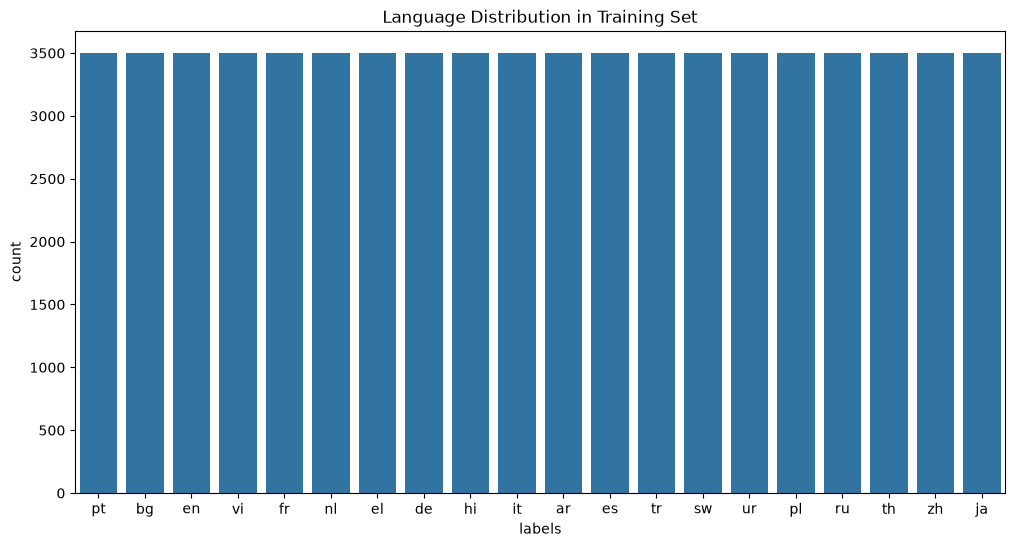

Text length statistics:
 count    70000.000000
mean       110.861414
std        103.106240
min          2.000000
25%         47.000000
50%         82.000000
75%        143.000000
max       2422.000000
Name: text_len, dtype: float64

Sample texts per language:
--- pt ---
os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão  ...
--- bg ---
размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до ...
--- zh ---
很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出 ...
--- th ---
สำหรับ ของเก่า ที่ จริงจัง ลอง   honeychurch   ของเก่า ที่ ไม่   29   สำหรับ เฟอร์นิเจอร์ และ เงิน ไ ...
--- ru ---
Он увеличил давление . ...


In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='labels', order=train_df['labels'].value_counts().index)
plt.title('Language Distribution in Training Set')
plt.show()

# Text length stats
train_df['text_len'] = train_df['text'].apply(len)
print("Text length statistics:\n", train_df['text_len'].describe())

# Sample texts per language
print("\nSample texts per language:")
for lang in train_df['labels'].unique()[:5]:
    print(f"--- {lang} ---")
    print(train_df[train_df['labels'] == lang]['text'].iloc[0][:100], "...")

## 3. Preprocessing

Lowercase, remove URLs/emails, keep Unicode chars (important for language ID).

In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    # Keeping unicode chars but replacing multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text'] = val_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

## 4. Feature Extraction

Using TF-IDF with character n-grams (3,4,5). Character n-grams work better than word-level features for language identification because they capture morphological patterns, suffixes, prefixes, and unique character combinations specific to languages, even for unseen or misspelled words.

In [5]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), sublinear_tf=True, max_features=300000)
X_train = vectorizer.fit_transform(train_df['clean_text'])
y_train = train_df['labels']

X_val = vectorizer.transform(val_df['clean_text'])
y_val = val_df['labels']

X_test = vectorizer.transform(test_df['clean_text'])
y_test = test_df['labels']

## 5. Train Models

Train Logistic Regression, LinearSVC, and MultinomialNB for comparison.

In [8]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),
    'LinearSVC': LinearSVC(random_state=42),
    'MultinomialNB': MultinomialNB()
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    print(f"{name} Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
    trained_models[name] = model

Training LogisticRegression...


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression Validation Accuracy: 0.9938
Training LinearSVC...
LinearSVC Validation Accuracy: 0.9949
Training MultinomialNB...
MultinomialNB Validation Accuracy: 0.9903


## 6. Evaluate Models

Evaluate on the test set.

In [9]:
best_model_name = 'LinearSVC'
best_f1 = 0

for name, model in trained_models.items():
    test_preds = model.predict(X_test)
    acc = accuracy_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds, average='macro')
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name

print(f"\nBest model is {best_model_name}")
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, best_preds))


--- LogisticRegression ---
Accuracy: 0.9923, Macro F1: 0.9923

--- LinearSVC ---
Accuracy: 0.9945, Macro F1: 0.9945

--- MultinomialNB ---
Accuracy: 0.9920, Macro F1: 0.9920

Best model is LinearSVC

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       0.99      1.00      1.00       500
          pl       1.00      0.99      1.00       500
          pt       0.99      0.99      0.99       500
          ru       

## 7. Confusion Matrix

Visualize the confusion matrix of the best model.

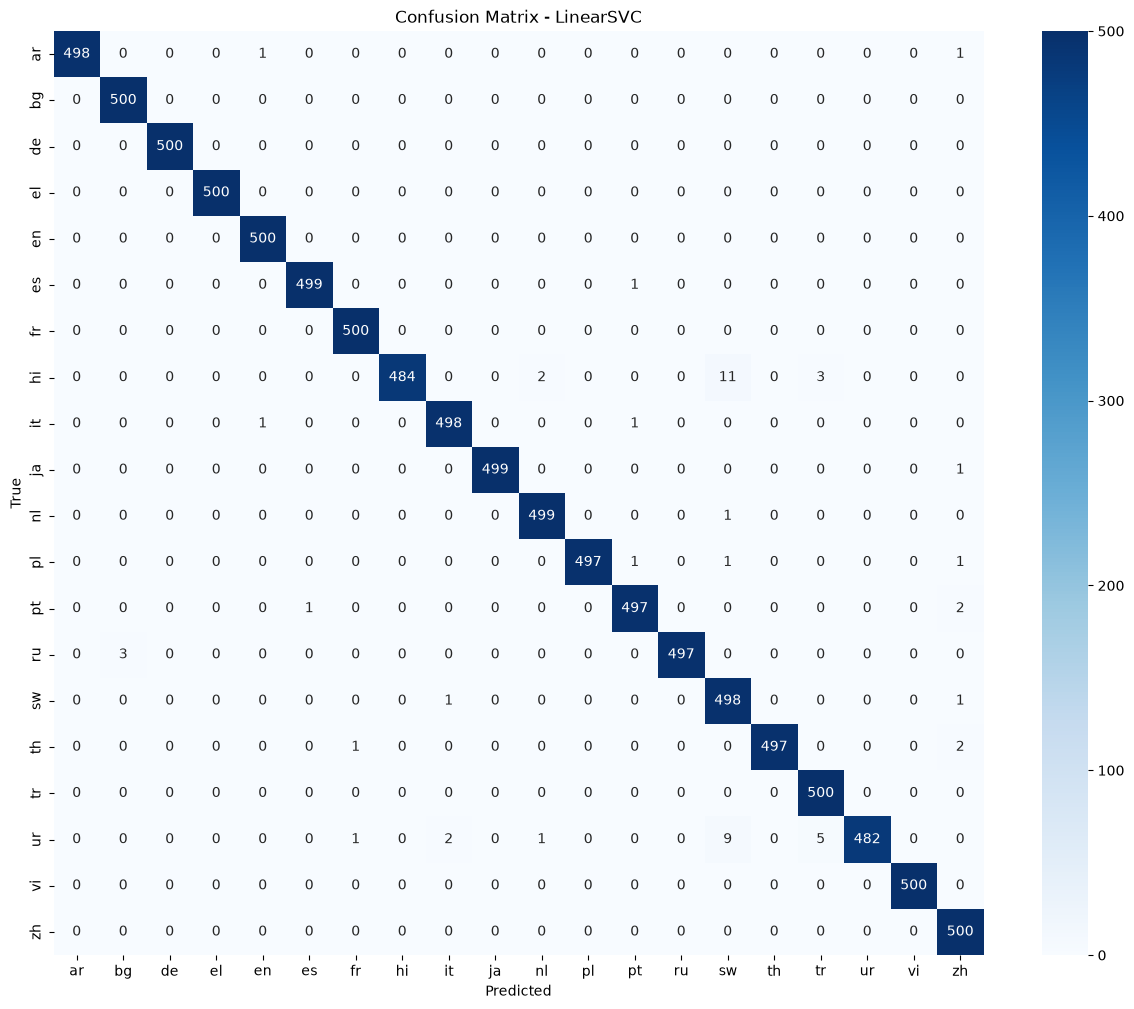

In [10]:
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 8. Save Model

Save the best model and vectorizer using joblib.

In [11]:
os.makedirs(str(LANG_MODEL_PATH.parent), exist_ok=True)
joblib.dump(best_model, str(LANG_MODEL_PATH))
joblib.dump(vectorizer, str(LANG_VECTORIZER_PATH))
print("Model and vectorizer saved successfully to", LANG_MODEL_PATH)


Model and vectorizer saved successfully to c:\Users\acer\Downloads\hello\proooojjj\rag_chatbot\models\lang_detect_model.pkl
